#### CMSE 381 Final Project
### &#9989; Group members: Jack Cienkus, Kathryn Tumavitch
### &#9989; Section_002
#### &#9989; Date

---

# What three factors lead to the highest exam scores on average? Why is this the case?

---

## Background and Motivation

_(Provide context for the problem.  **Clearly state the question(s) you set
out to answer.**)_

insert motivation here

---

## Methodology
_(How did you go about answering your question(s)? You should wrote some code here to demonstrate what the data is like and how in principle your method works. You can leave the variations of the related to specific results to the results section.)_

In [1]:
# you may want to import some modules here
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

spf_data = pd.read_csv("StudentPerformanceFactors.csv")

---

### Data
_(Describe the data you are using. What variables are you using? What they mean? Why did you choose them?)_

The data used in this study is from a data set called "Student Academic Performance Dataset" by a user on Kaggle named "ayeshasiddiqa123." The name explains what data is involved; It's student academic performance data. There's information about 6,607 students, and the information collected for each is as follows: `Hours_Studied`, which tracks the number of hours studied, `Attendance`, which tracks attendance as a percentage, `Parental_Involvement`, which classifies the amount of parental involvement as "Low", "Medium", or "High", `Access_to_Resources`, which classifies the student's access to resources, `Extracurricular_Activities`, which classifies whether or not a student had extracurricular activities as "Yes" or "No", `Sleep_Hours`, which tracks average hours of sleep, `Previous_Scores`, which tracks previous exam scores, `Motivation_Level`, which classifies motivation level as "Low", "Medium", or "High", `Internet_Access`, which classifies whether or not a student had internet access, `Tutoring_Sessions`, which tracks number of tutoring sessions, `Family_Income`, which classifies family income as "Low", "Medium", or "High", `Teacher_Quality`, which classifies teacher quality as "Low", "Medium", or "High", `School_Type`, which classifies type of school as "Public" or "Private", `Peer_Influence`, which classifies peer influence as "Positive", "Neutral", or "Negative", `Physical_Activity`, which tracks the amount of physical activity, `Learning_Disabilities`, which classifies whether or not they have a learning disability as "Yes" or "No", `Parental_Education_Level`, which classifies level of parental education as "High School", "College", or "Postgraduate", `Distance_From_Home`, which classifies distance between school and home as "Near", "Moderate", or "Far", `Gender`, which classifies gender as "Male" or "Female", and `Exam_Score`, which tracks their exam score. All features are used in this study. The cleaning done to this data consists of removing a row of data if there's an instance of a missing value. After doing this, the amount of rows became 6,378. See below for a peek into the data set.

In [2]:
# you may want to write some code to see what the data looks like
# Standard practice for removing rows in a Pandas dataset whose entries include NaN values
cleaned_spf_data = spf_data.copy().dropna()
cleaned_spf_data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


---

### Models for regression _(if applicable)_
_(What models will you be using for regression? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

We did linear regression using a standard train-test split for the data, and random forest regression with k-fold cross validation for the data.

---

### Random Forest Regressors using K-Fold CV on data

#### Predict exam scores with only quantitative features

In [14]:
# Create data set of predictors and column of exam scores
int_c_spf = cleaned_spf_data.copy().select_dtypes(include=['int64','float64'])
X_tree = int_c_spf.copy().drop(columns=["Exam_Score"])
y_tree = cleaned_spf_data["Exam_Score"].copy()

# Create the random forest regressor object
tree_reg_model = RandomForestRegressor(random_state=12)

# Use k-fold cross validation to calculate R^2 and RMSE scores of different subsets
cv_r2_scores = cross_val_score(tree_reg_model, X_tree, y_tree, cv=5, scoring='r2')
cv_neg_mse_scores = cross_val_score(tree_reg_model, X_tree, y_tree, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

# Print results
print(f"Individual R-squared scores: {cv_r2_scores.round(3)}")
print(f"Average R-squared: {round(cv_r2_scores.mean(),3)} (Standard Deviation: +/- {round(cv_r2_scores.std(),3)})")
print(f"Individual RMSE scores: {cv_rmse_scores.round(3)}")
print(f"Average RMSE: {round(cv_rmse_scores.mean(),3)} (Standard Deviation: +/- {round(cv_rmse_scores.std(),3)})")

Individual R-squared scores: [0.447 0.484 0.502 0.543 0.605]
Average R-squared: 0.516 (Standard Deviation: +/- 0.054)
Individual RMSE scores: [2.974 2.829 2.743 2.638 2.407]
Average RMSE: 2.718 (Standard Deviation: +/- 0.191)


---

### Predict exam scores with only qualitative features

In [15]:
# Create data set of predictors and column of exam scores
X_tree = cleaned_spf_data.copy().select_dtypes(include=['object'])
y_tree = cleaned_spf_data["Exam_Score"].copy()

# Convert any columns which contain string objects to integers
X_tree_encoded = pd.get_dummies(X_tree, drop_first=True)

# Create the random forest regressor object
tree_reg_model = RandomForestRegressor(random_state=12)

# Use k-fold cross validation to calculate R^2 and RMSE scores of different subsets
cv_r2_scores = cross_val_score(tree_reg_model, X_tree_encoded, y_tree, cv=5, scoring='r2')
cv_neg_mse_scores = cross_val_score(tree_reg_model, X_tree_encoded, y_tree, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

# Print results
print(f"Individual R-squared scores: {cv_r2_scores.round(3)}")
print(f"Average R-squared: {round(cv_r2_scores.mean(),3)} (Standard Deviation: +/- {round(cv_r2_scores.std(),3)})")
print(f"Individual RMSE scores: {cv_rmse_scores.round(3)}")
print(f"Average RMSE: {round(cv_rmse_scores.mean(),3)} (Standard Deviation: +/- {round(cv_rmse_scores.std(),3)})")

Individual R-squared scores: [-0.072 -0.053 -0.014 -0.042 -0.111]
Average R-squared: -0.058 (Standard Deviation: +/- 0.032)
Individual RMSE scores: [4.143 4.042 3.915 3.984 4.035]
Average RMSE: 4.024 (Standard Deviation: +/- 0.075)


---

#### Predict exam scores with every other feature

In [16]:
# Create data set of predictors and column of exam scores
X_tree = cleaned_spf_data.copy().drop(columns=["Exam_Score"])
y_tree = cleaned_spf_data["Exam_Score"].copy()

# Convert any columns which contain string objects to integers
X_tree_encoded = pd.get_dummies(X_tree, drop_first=True)

# Create the random forest regressor object
tree_reg_model = RandomForestRegressor(random_state=12)

# Use k-fold cross validation to calculate R^2 and RMSE scores of different subsets
cv_r2_scores = cross_val_score(tree_reg_model, X_tree_encoded, y_tree, cv=5, scoring='r2')
cv_neg_mse_scores = cross_val_score(tree_reg_model, X_tree_encoded, y_tree, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

# Print results
print(f"Individual R-squared scores: {cv_r2_scores.round(3)}")
print(f"Average R-squared: {round(cv_r2_scores.mean(),3)} (Standard Deviation: +/- {round(cv_r2_scores.std(),3)})")
print(f"Individual RMSE scores: {cv_rmse_scores.round(3)}")
print(f"Average RMSE: {round(cv_rmse_scores.mean(),3)} (Standard Deviation: +/- {round(cv_rmse_scores.std(),3)})")

Individual R-squared scores: [0.528 0.603 0.587 0.621 0.7  ]
Average R-squared: 0.608 (Standard Deviation: +/- 0.056)
Individual RMSE scores: [2.749 2.482 2.498 2.403 2.098]
Average RMSE: 2.446 (Standard Deviation: +/- 0.209)


---

### Linear Regressors using Forward Selection on data

#### Function used for forward selection and graphs

In [6]:
def forward_selection_with_plot(X, y, significance_level=0.05):
    selected_features = []
    remaining_features = list(X.columns)

    r2_scores = []
    features_count = []

    while remaining_features:
        results = []

        for feature in remaining_features:
            features_to_test = selected_features + [feature]

            X_model = sm.add_constant(X[features_to_test]).astype(float)
            model = sm.OLS(y, X_model).fit()

            p_value = model.pvalues[feature]
            r2 = model.rsquared_adj 

            results.append((feature, p_value, r2))

        results.sort(key=lambda x: x[1])
        best_feature, best_p_value, best_r2 = results[0]

        if best_p_value < significance_level:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)

            r2_scores.append(best_r2)
            features_count.append(len(selected_features))

            print(f"Selected: {best_feature} | p-value={best_p_value:.6f} | Adj R2={best_r2:.4f}")
        else:
            break

    return selected_features, features_count, r2_scores

---

#### Predict exam scores with only qualitative features

In [7]:
int_c_spf = cleaned_spf_data.select_dtypes(include=['int64', 'float64'])

X = int_c_spf.drop(columns=['Exam_Score'])
y = int_c_spf['Exam_Score']

X = X.astype(float)
y = y.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("=== Linear Regression ===")
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("\n=== Forward Selection ===")
selected_features, feature_count, r2_scores = forward_selection_with_plot(X_train, y_train)

print("\nFinal Selected Features:")
print(selected_features)


X_train_fs = sm.add_constant(X_train[selected_features]).astype(float)
X_test_fs = sm.add_constant(X_test[selected_features]).astype(float)

model_fs = sm.OLS(y_train, X_train_fs).fit()

y_pred_fs = model_fs.predict(X_test_fs)

print("\n=== Forward Selection Model ===")
print("R2 Score:", r2_score(y_test, y_pred_fs))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_fs)))

print(model_fs.summary())

=== Linear Regression ===
R2 Score: 0.6098137879934002
RMSE: 2.462362758370293

=== Forward Selection ===
Selected: Attendance | p-value=0.000000 | Adj R2=0.3313
Selected: Hours_Studied | p-value=0.000000 | Adj R2=0.5344
Selected: Previous_Scores | p-value=0.000000 | Adj R2=0.5638
Selected: Tutoring_Sessions | p-value=0.000000 | Adj R2=0.5877
Selected: Physical_Activity | p-value=0.000027 | Adj R2=0.5891

Final Selected Features:
['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

=== Forward Selection Model ===
R2 Score: 0.6102720061995421
RMSE: 2.460916486228
                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.589
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     1463.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               

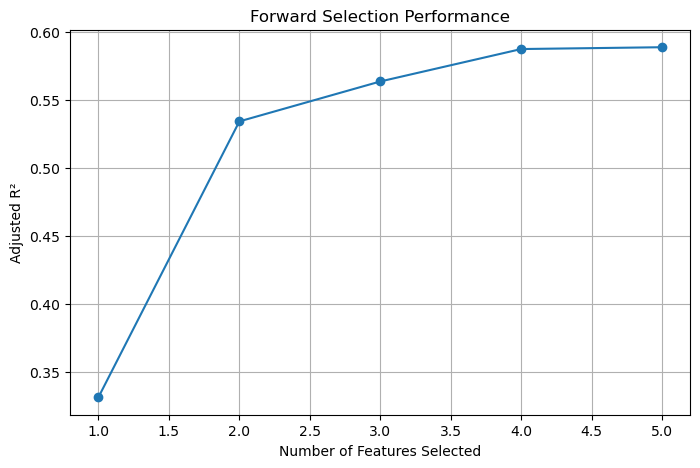

In [8]:
plt.figure(figsize=(8,5))
plt.plot(feature_count, r2_scores, marker='o')

plt.xlabel("Number of Features Selected")
plt.ylabel("Adjusted R²")
plt.title("Forward Selection Performance")

plt.grid(True)
plt.show()

---

#### Predict exam scores with only quantitative features

In [9]:
int_c_spf2 = cleaned_spf_data.select_dtypes(include=['object'])

X = pd.get_dummies(int_c_spf2, drop_first=True)
y = cleaned_spf_data['Exam_Score']

X = X.astype(float)
y = y.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("=== Linear Regression ===")
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("\n=== Forward Selection ===")
selected_features, feature_count, r2_scores = forward_selection_with_plot(X_train, y_train)

print("\nFinal Selected Features:")
print(selected_features)


X_train_fs = sm.add_constant(X_train[selected_features]).astype(float)
X_test_fs = sm.add_constant(X_test[selected_features]).astype(float)

model_fs = sm.OLS(y_train, X_train_fs).fit()

y_pred_fs = model_fs.predict(X_test_fs)

print("\n=== Forward Selection Model ===")
print("R2 Score:", r2_score(y_test, y_pred_fs))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_fs)))

print(model_fs.summary())

=== Linear Regression ===
R2 Score: 0.11230549326759309
RMSE: 3.714050811347517

=== Forward Selection ===
Selected: Access_to_Resources_Low | p-value=0.000000 | Adj R2=0.0164
Selected: Parental_Involvement_Low | p-value=0.000000 | Adj R2=0.0311
Selected: Parental_Involvement_Medium | p-value=0.000000 | Adj R2=0.0417
Selected: Access_to_Resources_Medium | p-value=0.000000 | Adj R2=0.0515
Selected: Parental_Education_Level_Postgraduate | p-value=0.000000 | Adj R2=0.0604
Selected: Family_Income_Low | p-value=0.000000 | Adj R2=0.0690
Selected: Learning_Disabilities_Yes | p-value=0.000000 | Adj R2=0.0763
Selected: Distance_from_Home_Near | p-value=0.000000 | Adj R2=0.0826
Selected: Peer_Influence_Positive | p-value=0.000000 | Adj R2=0.0889
Selected: Motivation_Level_Low | p-value=0.000000 | Adj R2=0.0942
Selected: Peer_Influence_Neutral | p-value=0.000018 | Adj R2=0.0973
Selected: Extracurricular_Activities_Yes | p-value=0.000011 | Adj R2=0.1006
Selected: Teacher_Quality_Medium | p-value=0

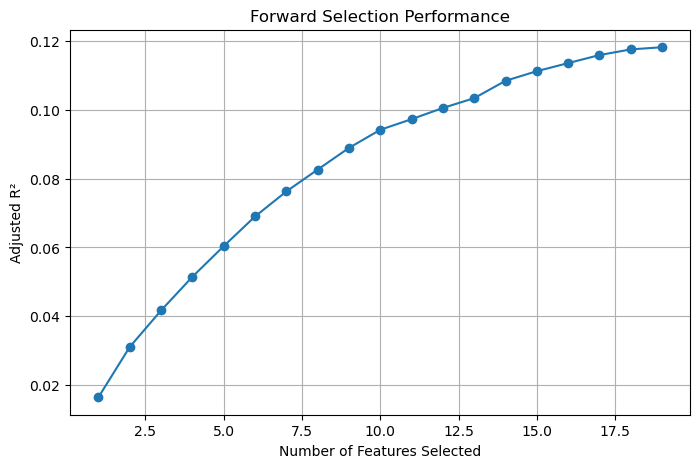

In [10]:
plt.figure(figsize=(8,5))
plt.plot(feature_count, r2_scores, marker='o')

plt.xlabel("Number of Features Selected")
plt.ylabel("Adjusted R²")
plt.title("Forward Selection Performance")

plt.grid(True)
plt.show()

---

#### Predict exam scores with every other feature

In [11]:
int_c_spf3 = cleaned_spf_data.drop(columns=['Exam_Score'])

X = pd.get_dummies(int_c_spf3, drop_first=True)
y = cleaned_spf_data['Exam_Score']

X = X.astype(float)
y = y.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("=== Linear Regression ===")
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("\n=== Forward Selection ===")
selected_features, feature_count, r2_scores = forward_selection_with_plot(X_train, y_train)

print("\nFinal Selected Features:")
print(selected_features)


X_train_fs = sm.add_constant(X_train[selected_features]).astype(float)
X_test_fs = sm.add_constant(X_test[selected_features]).astype(float)

model_fs = sm.OLS(y_train, X_train_fs).fit()

y_pred_fs = model_fs.predict(X_test_fs)

print("\n=== Forward Selection Model ===")
print("R2 Score:", r2_score(y_test, y_pred_fs))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_fs)))

print(model_fs.summary())

=== Linear Regression ===
R2 Score: 0.7314386522127074
RMSE: 2.0428563488918923

=== Forward Selection ===
Selected: Attendance | p-value=0.000000 | Adj R2=0.3313
Selected: Hours_Studied | p-value=0.000000 | Adj R2=0.5344
Selected: Previous_Scores | p-value=0.000000 | Adj R2=0.5638
Selected: Tutoring_Sessions | p-value=0.000000 | Adj R2=0.5877
Selected: Access_to_Resources_Low | p-value=0.000000 | Adj R2=0.6063
Selected: Parental_Involvement_Low | p-value=0.000000 | Adj R2=0.6260
Selected: Parental_Involvement_Medium | p-value=0.000000 | Adj R2=0.6379
Selected: Access_to_Resources_Medium | p-value=0.000000 | Adj R2=0.6487
Selected: Family_Income_Low | p-value=0.000000 | Adj R2=0.6576
Selected: Peer_Influence_Positive | p-value=0.000000 | Adj R2=0.6648
Selected: Parental_Education_Level_High School | p-value=0.000000 | Adj R2=0.6717
Selected: Motivation_Level_Low | p-value=0.000000 | Adj R2=0.6779
Selected: Distance_from_Home_Near | p-value=0.000000 | Adj R2=0.6834
Selected: Extracurric

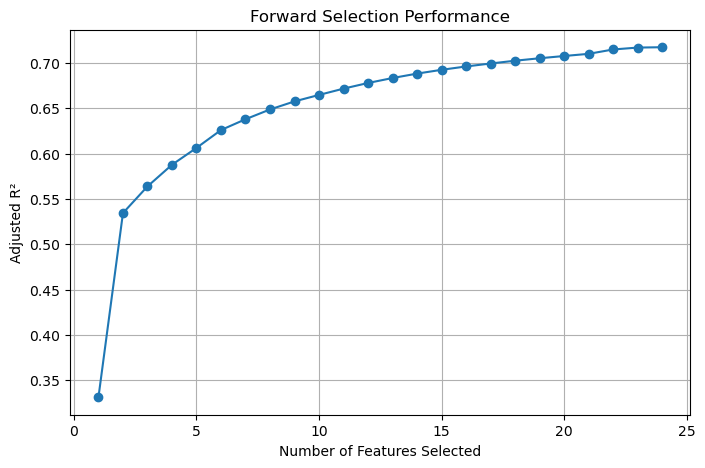

In [12]:
plt.figure(figsize=(8,5))
plt.plot(feature_count, r2_scores, marker='o')

plt.xlabel("Number of Features Selected")
plt.ylabel("Adjusted R²")
plt.title("Forward Selection Performance")

plt.grid(True)
plt.show()

---

### Other methods used _(if applicable)_

_(If this is a preprocessing step to prepare your data for regression or classification models, you should put this subsection before your explanation for the regression or classification models.)_

_(What method did you use otherwise? Why did you choose to use them? What questions would you answer with them? How would you evaluate the results? What cross-validation method did you use when applicable?)_

In [13]:
# you may add some code here to show how the method works in principle

---

## Results

_(What did you find when you carried out your methods? Some of your code related to
presenting results/figures/data may be replicated from the methods section or may only be present in
this section. All of the plots that you plan on using for your presentation should be present in this
section)_

insert results here

---

## Discussion and Conclusion

_(What did you learn from your results? What obstacles did you run into? What would you do differently next time? Clearly provide quantitative answers to your question(s)?  At least one of your questions should be answered with numbers.  That is, it is not sufficient to answer "yes" or "no", but rather to say something quantitative such as variable 1 increased roughly 10% for every 1 year increase in variable 2.)_

insert discussion and conclusion here

---

## Author contribution

_(Please describe the contribution of each member of group)._

Jack's Contributions: Random Forest Regressors, Data, Discussion & Conclusion

Kate's Contributions: Background & Motivation, Linear Regressors

---

## References

_(List the source(s) for any data and/or literature cited in your project.  Ideally, this should be formatted using a formal citation format (MLA or APA or other, your choice!).   Multiple free online citation generators are available such as <a href="http://www.easybib.com/style">http://www.easybib.com/style</a>. **Important:** if you use **any** code that you find on the internet for your project you **must** cite it or you risk losing most/all of the points for you project.)_

list references here

---